Trained with 500 games, average test reward: -54.378
Trained with 1000 games, average test reward: -46.208
Trained with 1500 games, average test reward: -36.674
Trained with 2000 games, average test reward: -37.97
Trained with 2500 games, average test reward: -34.774


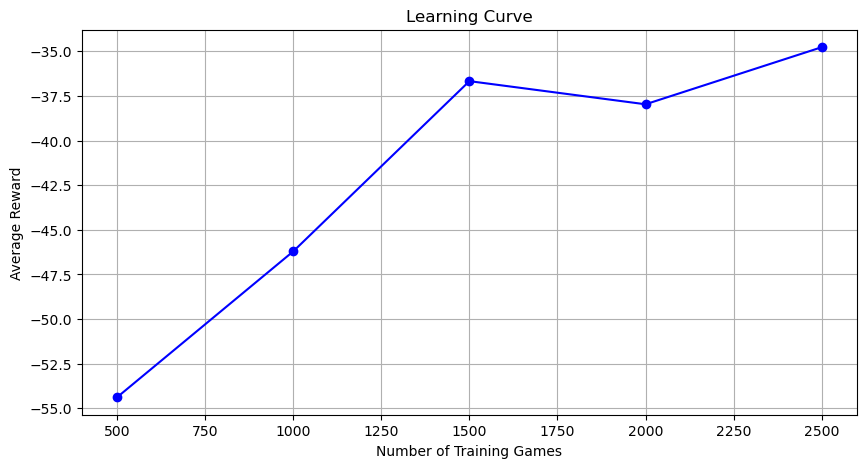

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from maze import Maze
from random import randint, uniform
import maze


class MazeLearner:
    def __init__(self, num_train_games=None, num_test_games=None):
        #generate the maze using Maze from maze.py
        self.the_maze = Maze()

        #initalize the q-table containing the q-value for every possible action 
        self.initialize_q_table()
        
        self.alpha = 0.01  # Learning rate
        self.gamma = 0.9  # Discount factor
        self.epsilon = 0.03  # Exploration rate

        if num_train_games and num_test_games:
            #if the number of testing and training agmes are actually specified
            self.train(num_train_games)
            self.test(num_test_games)

    def test_pick_action(self, player_point, opponent_point):
        #uses the get_state_number function further down to figure out the state index (which is used to access the Q-table)
        #considering both the player and opponent's state positions 
        state = self.get_state_number(player_point, opponent_point)
        #from the current state, find the q-value in the q-table row (every possible action from this state)
        #that corresponds to the 'best' action according to what has been learned. 
        #When the q-table is initialized, its all zeroes, so, as new spots are discorvered and given a value, those values 
        #will be greater than the spots that have not been explorered yet, which are still zeroes. 
        return np.argmax(self.q_table[state])


    def initialize_q_table(self):
        #this sets the maximum manhatan distance
        #the manhatan distance is the absolute difference bertween two points. In this case, the maze is 10 x 10, so
        #the largest possible distance would be |10-0| + |10-0| = 20, which is exactly double the sie of the maze
        max_distance = 2 * self.the_maze.MAZE_SIZE
        #calculate the total number of possible state configs
        state_space_size = (self.the_maze.MAZE_SIZE ** 2) * (self.the_maze.MAZE_SIZE ** 2) * max_distance
        #Create the q-table based on how many possible states there are
        self.q_table = np.zeros((state_space_size, self.the_maze.MAX_ACTION + 1))
        

    def get_state_number(self, player_point, opponent_point):
        # Calculate a index for the player's position in a 1D array representation of the maze
        p_idx = player_point.y * self.the_maze.MAZE_SIZE + player_point.x
        # Calculate a index for the opponent's position in a 1D array representation of the maze
        o_idx = opponent_point.y * self.the_maze.MAZE_SIZE + opponent_point.x
        # Compute the Manhattan distance from the player's position to the goal position
        distance = abs(player_point.x - self.the_maze.goal.x) + abs(player_point.y - self.the_maze.goal.y)  # Manhattan distance
        # Combine player index, opponent index, and distance into a single state index
        state_index = (p_idx * (self.the_maze.MAZE_SIZE ** 2) + o_idx) * (2 * self.the_maze.MAZE_SIZE) + distance
        return state_index
        

    def train_pick_action(self, player_point, opponent_point):
        # Calculate the state index for the current positions of the player and opponent.
        state = self.get_state_number(player_point, opponent_point)
        # Randomly decide whether to explore or exploit based on the epsilon value.
        # If a random number between 0 and 1 is greater than epsilon, proceed to exploit (choose the best known action).
        # The epsilon value I provided at the top is 0.03, and so, 97% of the time the algorithm will exploit
        if uniform(0, 1) > self.epsilon:
            # Exploit: Choose the action with the highest Q-value for the current state from the Q-table.
            action = np.argmax(self.q_table[state])
        else:
            # Explore: Choose a random action to perform. This helps in discovering new strategies.Can choose from the actions 0-4
            action = randint(0, self.the_maze.MAX_ACTION)
        return action
        

    def train_learner(self, player_point, opponent_point, action, reward):
    # Retrieve the current state index using the player's and opponent's initial positions
    current_state = self.get_state_number(player_point, opponent_point)
    # Update the player's position based on the chosen action
    new_player_point = self.update_player_position(player_point, action)
    # Keep the opponent's position unchanged in this step
    new_opponent_point = opponent_point
    # Calculate the new state index after the player's move
    next_state = self.get_state_number(new_player_point, new_opponent_point)
    # Calculate the maximum future reward that can be achieved from the new state
    future_rewards = np.max(self.q_table[next_state])
    # Update the Q-value for the current state and action using the Q-learning formula
    self.q_table[current_state, action] += self.alpha * (reward + self.gamma * future_rewards - self.q_table[current_state, action])

    def train(self, num_games, verbose=False):
        # Loop over the number of games to play for training
        for i in range(num_games):
            # Initialize the maze for a new game
            self.the_maze.initialize()
            total_reward = 0  # Initialize total reward for the game
            while True:
                # Fetch the current locations of the player and opponent
                player_point, opponent_point = self.the_maze.current_locations()
                # Decide on an action based on the current state
                action = self.train_pick_action(player_point, opponent_point)
                # Execute the chosen action and get the reward
                reward = self.the_maze.execute_action(action)
                # Train the learner with the new data
                self.train_learner(player_point, opponent_point, action, reward)
                total_reward += reward  # Accumulate the reward
                # Break if a terminal state is reached
                if reward != self.the_maze.REWARD_OTHER:
                    break
            # Optionally print the reward for the training game. I can just change verbose to true in the function definition to 
            #get the print-out
            if verbose:
                print(f"Reward for training game {i}: {total_reward}")
    
    def test(self, num_games, verbose=False):
        total_rewards = 0  # Initialize total rewards accumulated over all test games
        for i in range(num_games):
            self.the_maze.initialize()  # Reinitialize the maze for each game
            while True:
                player_point, opponent_point = self.the_maze.current_locations()
                action = self.test_pick_action(player_point, opponent_point)
                reward = self.the_maze.execute_action(action)
                total_rewards += reward
                if reward != self.the_maze.REWARD_OTHER:
                    break
        # Optionally print the average reward from testing. Again, if verbose in the function definition is true, these statements will print
        if verbose:
            print(f"Average reward from testing: {total_rewards / num_games}")
        return total_rewards / num_games
    
    def update_player_position(self, player_point, action):
        # Initialize new_position with current player_point
        new_position = player_point
        # Update player position based on the action taken (only 1-4 since a 0 is no action)
        if action == self.the_maze.ACTION_UP:
            # Move player up within the bounds of the maze
            new_position = Point(max(0, player_point.x - 1), player_point.y)
        elif action == self.the_maze.ACTION_DOWN:
            # Move player down within the bounds of the maze
            new_position = Point(min(self.the_maze.MAZE_SIZE - 1, player_point.x + 1), player_point.y)
        elif action == self.the_maze.ACTION_LEFT:
            # Move player left within the bounds of the maze
            new_position = Point(player_point.x, max(0, player_point.y - 1))
        elif action == self.the_maze.ACTION_RIGHT:
            # Move player right within the bounds of the maze
            new_position = Point(player_point.x, min(self.the_maze.MAZE_SIZE - 1, player_point.y + 1))
        return new_position

def run_experiment(training_games, testing_games):
    results = []
    for num_train in training_games:
        # Initialize Maze with the training and testing game numbers
        learner = MazeLearner(num_train, testing_games)
        # Test the learner and get the average reward
        avg_reward = learner.test(testing_games)
        results.append(avg_reward)
        print(f"Trained with {num_train} games, average test reward: {avg_reward}")
    return results

if __name__ == "__main__":
    training_games = [500, 1000, 1500, 2000, 2500]
    testing_games = 500
    # Run the experiment and gather performance data
    performance = run_experiment(training_games, testing_games)

    # Plot the learning curve based on training games and average rewards
    plt.figure(figsize=(10, 5))
    plt.plot(training_games, performance, marker='o', linestyle='-', color='b')
    plt.title('Learning Curve')
    plt.xlabel('Number of Training Games')
    plt.ylabel('Average Reward')
    plt.grid(True)
    plt.show()


In [ ]:
#Summery:

#As the number of training games increased, the average reward got better. Though, the averge reward was still negetive.
#The thing to do would be to change the alpha, gamma, and epsilon parameters to experement calculating different Q-value. Another thing to note is that
#very often, the algorithm was running into timeouts. Around 50% of games the algorithm lost due to a timeout, and not being caught. 
#The maximum number of actions is currently 50, so I'm not entirly sure how it couldn't find a route in that time. I'd have to analyse things more. 